<a href="https://colab.research.google.com/github/toche7/SlideAdvanceDSBDI/blob/main/notebook/TelCo_Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 1: การทำนายการเลิกใช้งานของลูกค้า (Customer Churn Prediction)

สมุดบันทึกนี้จะแนะนำขั้นตอนการสร้างแบบจำลองการทำนายการเลิกใช้งานของลูกค้า โดยเริ่มตั้งแต่การโหลดข้อมูล การทำความสะอาดข้อมูล การวิเคราะห์ข้อมูลเบื้องต้น ไปจนถึงการสร้างและประเมินแบบจำลอง Machine Learning หลายประเภท

## 1. การโหลดและการสำรวจข้อมูล

ส่วนนี้จะทำการโหลดชุดข้อมูล 'Telco Customer Churn' ลงใน DataFrame ของ Pandas และสำรวจโครงสร้างข้อมูล รวมถึงข้อมูลสรุปสถิติเพื่อทำความเข้าใจลักษณะของข้อมูลเบื้องต้น

In [6]:
import pandas as pd

# Load the Telco Customer Churn dataset from the provided file path
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 2. การทำความสะอาดข้อมูล

ในส่วนนี้ เราจะจัดการกับคอลัมน์ 'TotalCharges' ซึ่งเป็นประเภท object และอาจมีค่าที่ไม่ใช่ตัวเลข เราจะแปลงให้เป็นตัวเลขและจัดการกับค่าที่หายไปโดยการเติมค่ามัธยฐาน เพื่อให้ข้อมูลพร้อมสำหรับการวิเคราะห์และสร้างแบบจำลอง

In [9]:
# Convert 'TotalCharges' to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check for missing values created by the conversion
missing_total_charges = df['TotalCharges'].isnull().sum()
print(f"Number of missing values in 'TotalCharges' after conversion: {missing_total_charges}")

# Handle missing values in TotalCharges, e.g., by filling with the median or dropping rows
# For this dataset, let's fill with the median, as it's a small number of missing values.
if missing_total_charges > 0:
    median_total_charges = df['TotalCharges'].median()
    df['TotalCharges'].fillna(median_total_charges, inplace=True)
    print(f"Filled missing 'TotalCharges' with median value: {median_total_charges:.2f}")

# Verify the data type and check for any remaining NaNs
print("\nUpdated 'TotalCharges' info:")
df['TotalCharges'].info()

Number of missing values in 'TotalCharges' after conversion: 11
Filled missing 'TotalCharges' with median value: 1397.47

Updated 'TotalCharges' info:
<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: TotalCharges
Non-Null Count  Dtype  
--------------  -----  
7043 non-null   float64
dtypes: float64(1)
memory usage: 55.2 KB


/tmp/ipykernel_13049/3582259200.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(median_total_charges, inplace=True)


## 3. การแสดงภาพข้อมูล

ส่วนนี้จะสร้างฮิสโตแกรมสำหรับคุณลักษณะที่เป็นตัวเลขและแผนภูมินับ (count plots) สำหรับคุณลักษณะที่เป็นหมวดหมู่ เพื่อแสดงการกระจายตัวของข้อมูล ช่วยให้เข้าใจโครงสร้างข้อมูลและระบุรูปแบบที่เป็นไปได้

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


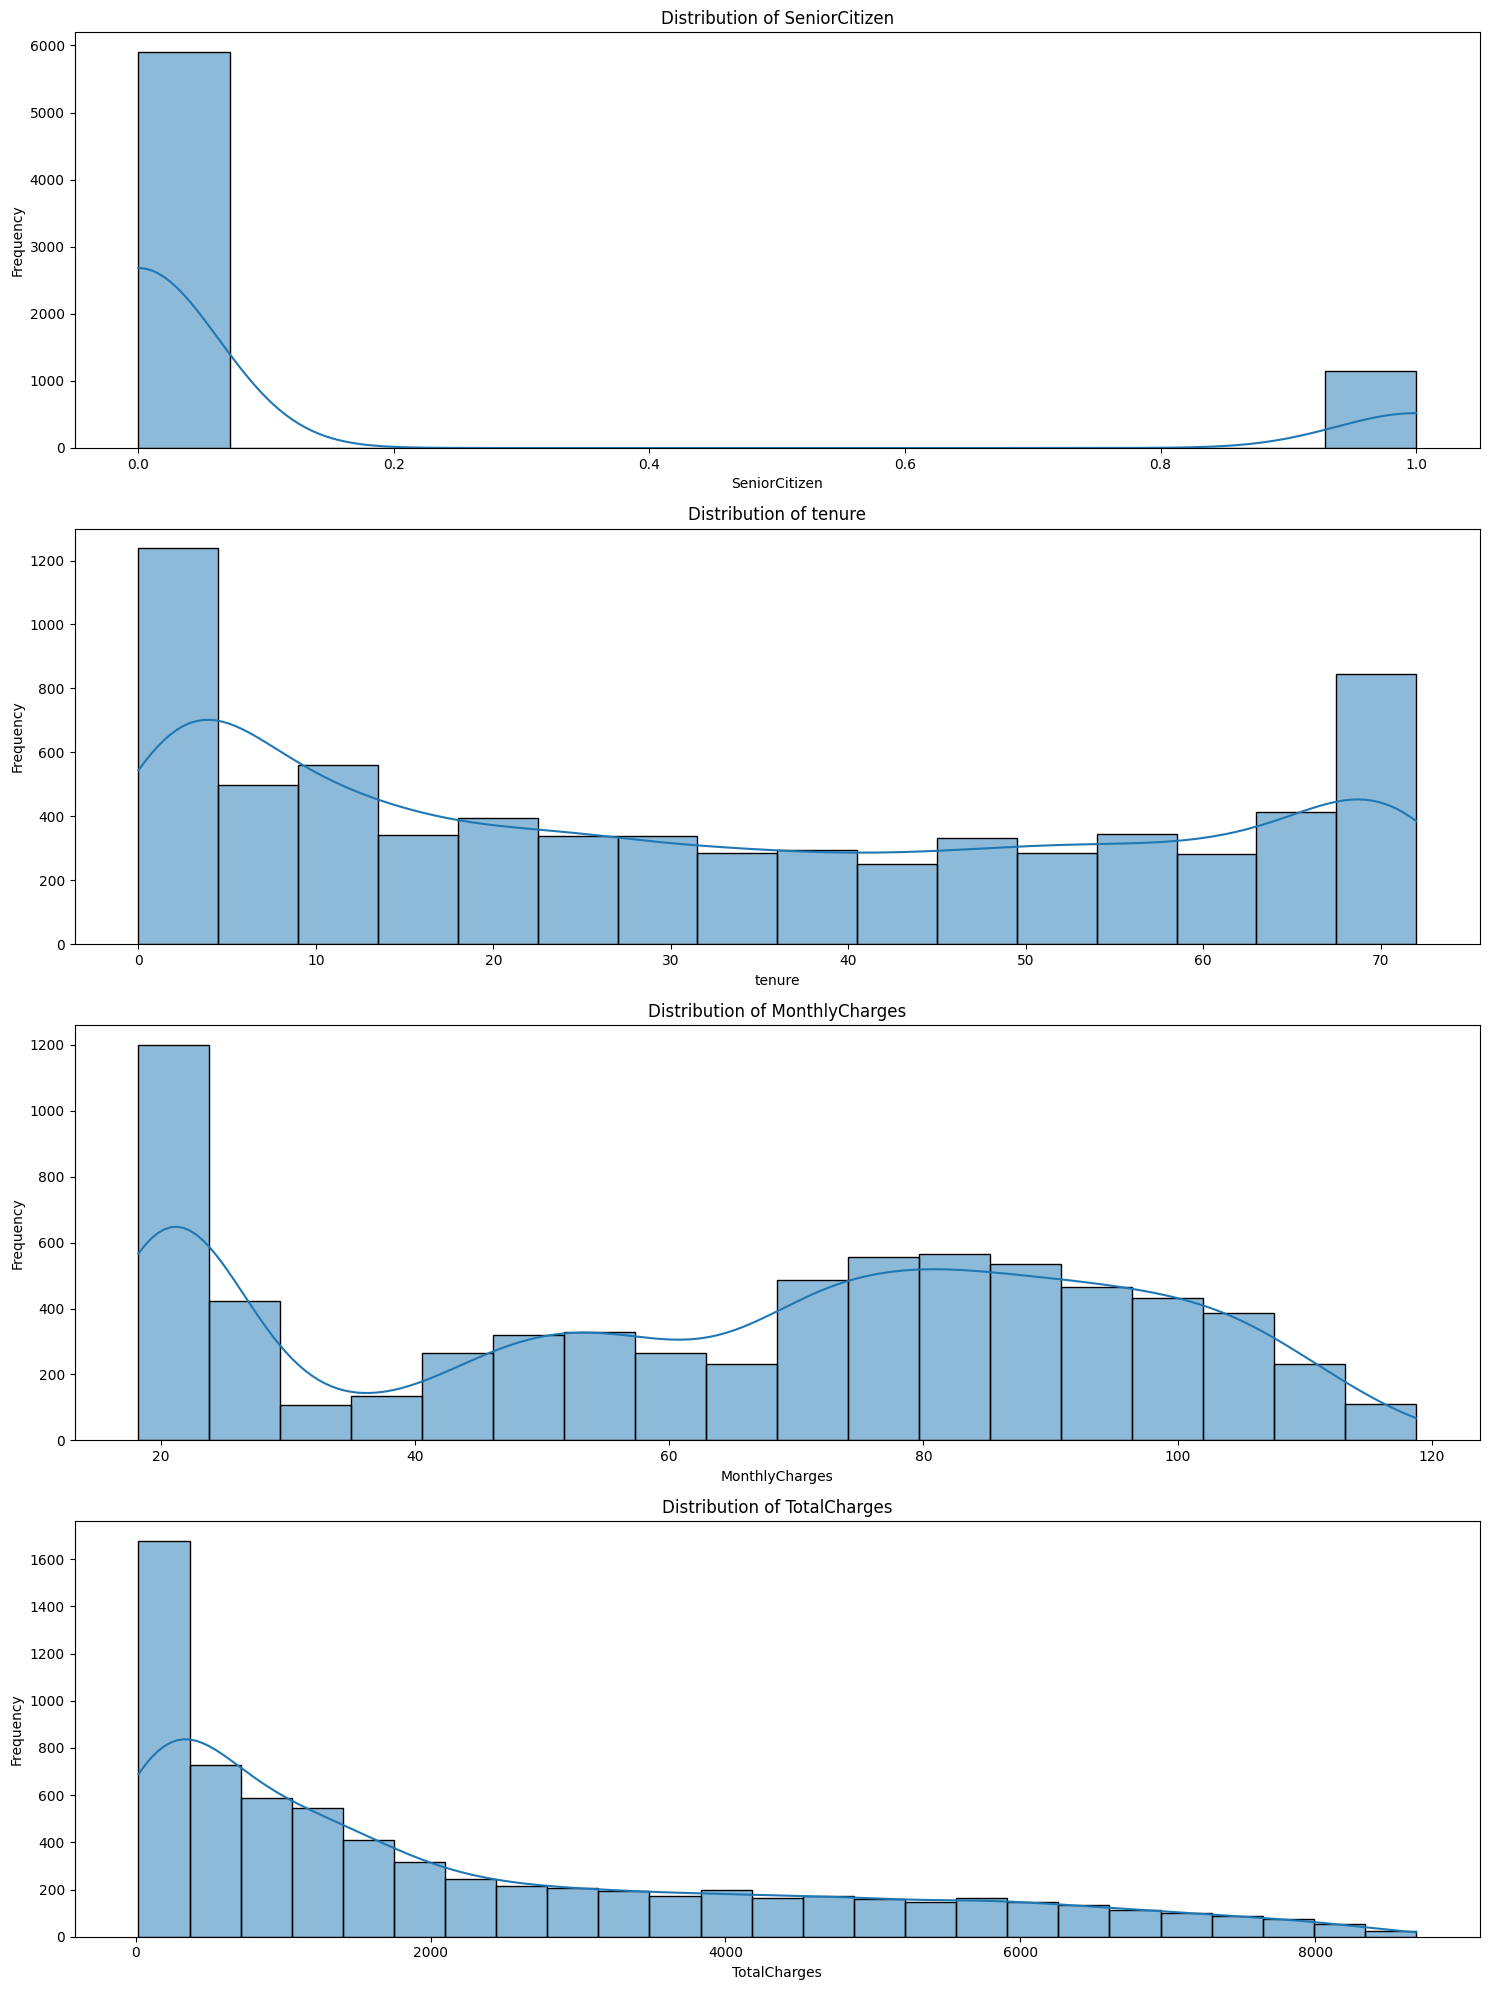

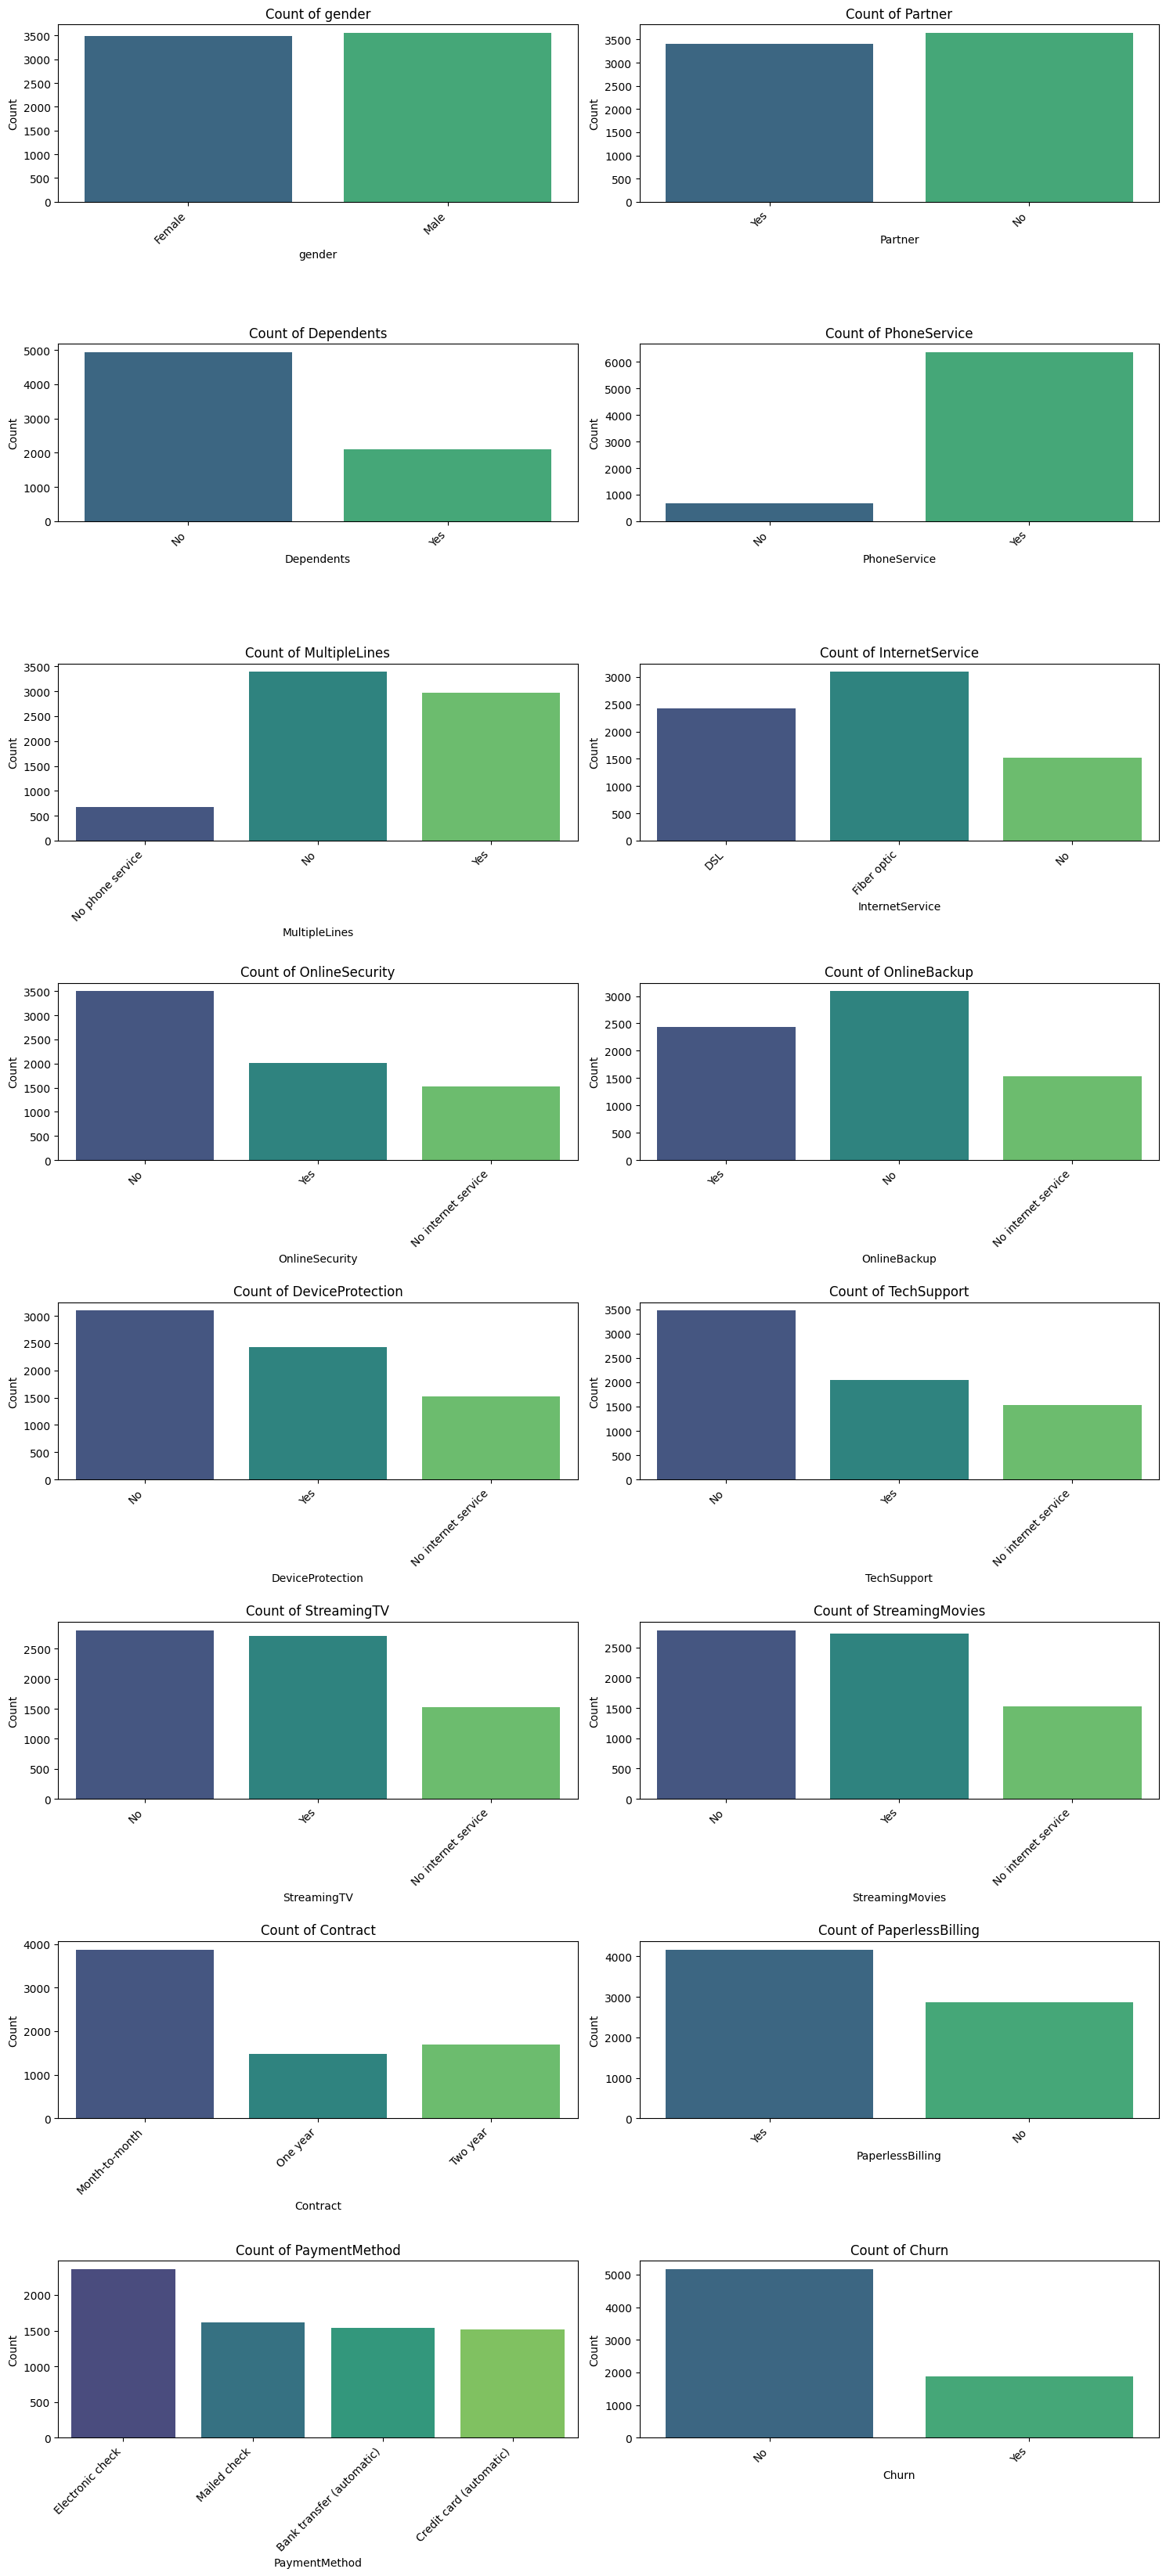

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical and categorical columns after 'TotalCharges' conversion
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Exclude 'customerID' from categorical columns for plotting
if 'customerID' in categorical_cols:
    categorical_cols.remove('customerID')

print(f"Numerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")

# Plot histograms for numerical columns
plt.figure(figsize=(15, 5 * len(numerical_cols)))
for i, col in enumerate(numerical_cols):
    plt.subplot(len(numerical_cols), 1, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Plot count plots for categorical columns
plt.figure(figsize=(15, 4 * len(categorical_cols)))
for i, col in enumerate(categorical_cols):
    plt.subplot(len(categorical_cols), 2, i + 1) # Adjust subplot layout for better visualization
    sns.countplot(data=df, x=col, palette='viridis', hue=col, legend=False)
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.show()

## 4. การเตรียมข้อมูลสำหรับการฝึกโมเดล

ก่อนการฝึกโมเดล เราจะทำการ One-Hot Encoding สำหรับคุณลักษณะที่เป็นหมวดหมู่ และปรับสเกล (Standard Scaling) คุณลักษณะที่เป็นตัวเลข รวมถึงการจัดการกับคอลัมน์ `customerID` เพื่อให้ข้อมูลพร้อมสำหรับการนำไปใช้กับโมเดลการเรียนรู้ของเครื่อง

### Data Preprocessing for Model Training

Before training a machine learning model, I'll preprocess the data by:
1.  **One-Hot Encoding**: Convert categorical features into a numerical format suitable for modeling.
2.  **Feature Scaling**: Scale numerical features to a standard range to prevent features with larger values from dominating the learning process.

In [15]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define target variable
X = df.drop('Churn', axis=1)
y = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0) # Convert 'Yes'/'No' to 1/0

# Identify categorical and numerical columns again, excluding customerID
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# Remove 'customerID' from features as it's just an identifier and should not be used in the model
if 'customerID' in categorical_features:
    categorical_features = categorical_features.drop('customerID')

# Ensure 'customerID' is not in numerical_features either, although it shouldn't be by dtypes
if 'customerID' in numerical_features:
    numerical_features = numerical_features.drop('customerID')

print(f"Features to be one-hot encoded: {list(categorical_features)}")
print(f"Features to be scaled: {list(numerical_features)}")

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop' # Explicitly drop any columns not specified for transformation (like customerID)
)

# Apply preprocessing
X_processed = preprocessor.fit_transform(X)

print(f"Shape of processed features: {X_processed.shape}")

# Get feature names after one-hot encoding
onehot_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = list(numerical_features) + list(onehot_feature_names)

# Convert processed features back to DataFrame for better inspection if needed
# This step should now work correctly as 'customerID' is dropped and column count matches
X_processed_df = pd.DataFrame(X_processed, columns=all_feature_names)
print("\nFirst 5 rows of processed data:")
display(X_processed_df.head())

Features to be one-hot encoded: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Features to be scaled: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Shape of processed features: (7043, 45)

First 5 rows of processed data:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-0.439916,-1.277445,-1.160323,-0.994242,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,-0.439916,0.066327,-0.259629,-0.173244,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,-0.439916,-1.236724,-0.362660,-0.959674,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,-0.439916,0.514251,-0.746535,-0.194766,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,-0.439916,-1.236724,0.197365,-0.940470,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


## 5. การแบ่งข้อมูลเป็นชุดฝึกและชุดทดสอบ

ส่วนนี้จะแบ่งข้อมูลที่ผ่านการประมวลผลแล้วออกเป็นชุดฝึก (Training Set) และชุดทดสอบ (Testing Set) ด้วยอัตราส่วน 80:20 เพื่อใช้ในการฝึกโมเดลและประเมินประสิทธิภาพของโมเดลบนข้อมูลที่ไม่เคยเห็นมาก่อน

In [17]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (5634, 45)
X_test shape: (1409, 45)
y_train shape: (5634,)
y_test shape: (1409,)


## 6. การฝึกโมเดลพื้นฐาน (Logistic Regression)

เราจะเริ่มต้นด้วยการฝึกโมเดล Logistic Regression ซึ่งเป็นโมเดลพื้นฐานที่ดีสำหรับปัญหาการจำแนกประเภทแบบไบนารี โดยจะมีการใช้ `class_weight='balanced'` เพื่อจัดการกับข้อมูลที่ไม่สมดุล

In [22]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
baseline_model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced') # 'liblinear' is good for small datasets and handles L1/L2 penalties
baseline_model.fit(X_train, y_train)

print("Baseline Logistic Regression model trained successfully with class weights.")

Baseline Logistic Regression model trained successfully with class weights.


## 7. การประเมินโมเดลพื้นฐาน

ในส่วนนี้จะประเมินประสิทธิภาพของโมเดล Logistic Regression โดยใช้ตัวชี้วัดต่างๆ เช่น ความแม่นยำ (accuracy), ความแม่นยำ (precision), การเรียกคืน (recall), F1-score และ ROC AUC พร้อมแสดง Confusion Matrix เพื่อให้เห็นภาพรวมของผลลัพธ์


--- Baseline Model Performance ---
Accuracy: 0.7381
Precision: 0.5043
Recall: 0.7834
F1-Score: 0.6136
ROC AUC: 0.8415

Confusion Matrix:
[[747 288]
 [ 81 293]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



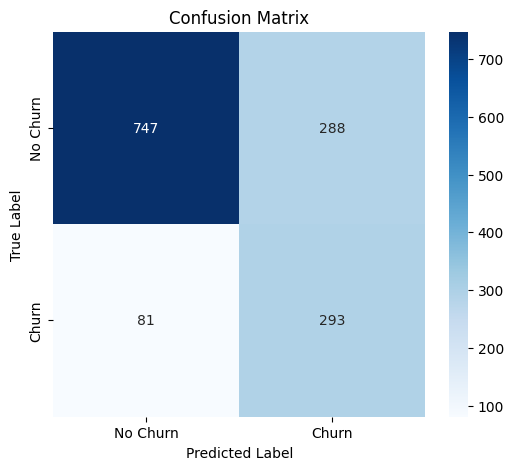

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Make predictions on the test set
y_pred = baseline_model.predict(X_test)
y_pred_proba = baseline_model.predict_proba(X_test)[:, 1] # Probability of the positive class (churn=1)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"\n--- Baseline Model Performance ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"\nConfusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 8. การวิเคราะห์ข้อมูลที่ไม่สมดุล

ส่วนนี้จะวิเคราะห์และแสดงให้เห็นว่าชุดข้อมูลมีความไม่สมดุลอย่างไรในเรื่องของคลาสเป้าหมาย 'Churn' และอธิบายถึงความสำคัญของการจัดการกับปัญหานี้ เพื่อให้แน่ใจว่าโมเดลไม่ได้ให้น้ำหนักกับคลาสส่วนใหญ่มากเกินไป

Churn Distribution (Percentage):
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


/tmp/ipykernel_13049/2602230692.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_distribution.index, y=churn_distribution.values, palette='viridis')


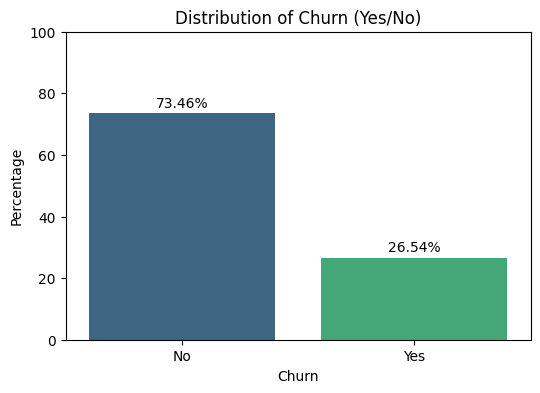


As you can see, the dataset is imbalanced. Approximately 73.5% of customers do not churn (No), while about 26.5% do churn (Yes).

**Why is this important?**

When training a model on imbalanced data, the model tends to be biased towards the majority class ('No Churn' in this case). This is because misclassifying the minority class ('Churn') has less impact on overall accuracy, leading the model to prioritize correctly classifying the majority class.

This bias can lead to:
- **Poor Recall for the Minority Class**: The model might struggle to identify actual churners, as seen in our current model's recall for 'Churn' (0.56).
- **Misleading Accuracy**: High overall accuracy can be deceptive if the model is simply predicting the majority class most of the time.

**Do we need to work with imbalanced data?**

Yes, it is highly recommended to address this imbalance, especially for a churn prediction problem where correctly identifying churners (the minority class) is often the primary busin

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the distribution of the 'Churn' target variable
churn_distribution = df['Churn'].value_counts(normalize=True) * 100
print("Churn Distribution (Percentage):")
print(churn_distribution)

# Visualize the distribution
plt.figure(figsize=(6, 4))
sns.barplot(x=churn_distribution.index, y=churn_distribution.values, palette='viridis')
plt.title('Distribution of Churn (Yes/No)')
plt.xlabel('Churn')
plt.ylabel('Percentage')
plt.ylim(0, 100)
for index, value in enumerate(churn_distribution.values):
    plt.text(index, value + 2, f'{value:.2f}%', ha='center')
plt.show()

print("\nAs you can see, the dataset is imbalanced. Approximately 73.5% of customers do not churn (No), while about 26.5% do churn (Yes).")
print("\n**Why is this important?**\n")
print("When training a model on imbalanced data, the model tends to be biased towards the majority class ('No Churn' in this case). This is because misclassifying the minority class ('Churn') has less impact on overall accuracy, leading the model to prioritize correctly classifying the majority class.")
print("\nThis bias can lead to:")
print("- **Poor Recall for the Minority Class**: The model might struggle to identify actual churners, as seen in our current model's recall for 'Churn' (0.56).")
print("- **Misleading Accuracy**: High overall accuracy can be deceptive if the model is simply predicting the majority class most of the time.")
print("\n**Do we need to work with imbalanced data?**\n")
print("Yes, it is highly recommended to address this imbalance, especially for a churn prediction problem where correctly identifying churners (the minority class) is often the primary business objective. Neglecting it can lead to a model that is not truly effective at its intended purpose.")
print("\n**Next Steps to address imbalance could include:**\n")
print("- **Resampling Techniques**: Oversampling the minority class (e.g., SMOTE) or undersampling the majority class.")
print("- **Using different evaluation metrics**: Focusing on metrics like Precision, Recall, F1-score, and ROC AUC, which are more informative for imbalanced datasets, as we have already started to do.")
print("- **Adjusting class weights** within the model (some models like Logistic Regression support this).")
print("- **Ensemble Methods**: Algorithms designed to handle imbalance or using ensembles with resampling.")

## 9. การพัฒนาโมเดลตัวเลือก: Decision Tree, Random Forest, และ XGBoost

ในส่วนนี้ เราจะพัฒนาและประเมินโมเดลเพิ่มเติม ได้แก่ Decision Tree, Random Forest และ XGBoost โดยจะมีการปรับใช้ `class_weight` หรือ `scale_pos_weight` เพื่อจัดการกับข้อมูลที่ไม่สมดุล และเปรียบเทียบประสิทธิภาพกับโมเดล Logistic Regression.


Developing Decision Tree Classifier...

--- Decision Tree Classifier Performance ---
Accuracy: 0.7282
Precision: 0.4879
Recall: 0.4840
F1-Score: 0.4859
ROC AUC: 0.6504

Confusion Matrix:
[[845 190]
 [193 181]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.82      0.82      1035
           1       0.49      0.48      0.49       374

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409



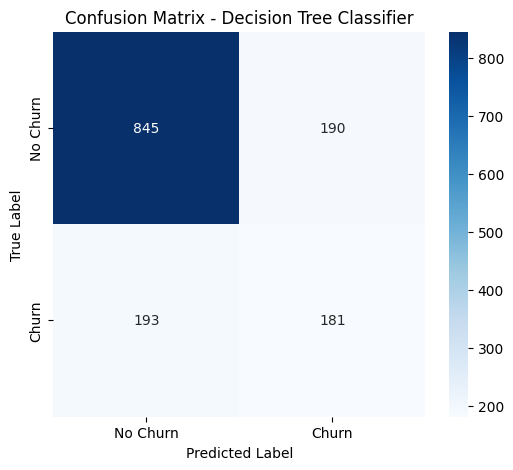


Developing Random Forest Classifier...

--- Random Forest Classifier Performance ---
Accuracy: 0.7842
Precision: 0.6232
Recall: 0.4733
F1-Score: 0.5380
ROC AUC: 0.8193

Confusion Matrix:
[[928 107]
 [197 177]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1035
           1       0.62      0.47      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409



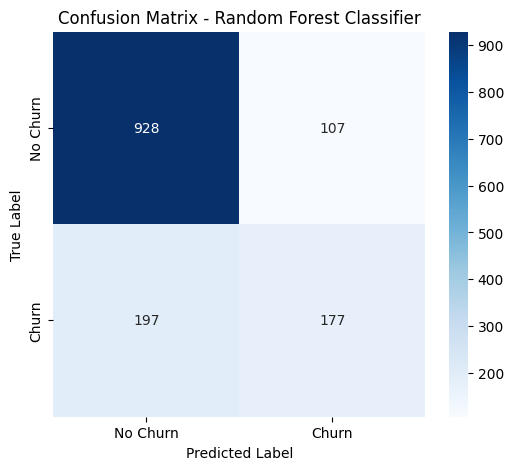


Developing XGBoost Classifier...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:06:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- XGBoost Classifier Performance ---
Accuracy: 0.7523
Precision: 0.5263
Recall: 0.6684
F1-Score: 0.5889
ROC AUC: 0.8187

Confusion Matrix:
[[810 225]
 [124 250]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.78      0.82      1035
           1       0.53      0.67      0.59       374

    accuracy                           0.75      1409
   macro avg       0.70      0.73      0.71      1409
weighted avg       0.78      0.75      0.76      1409



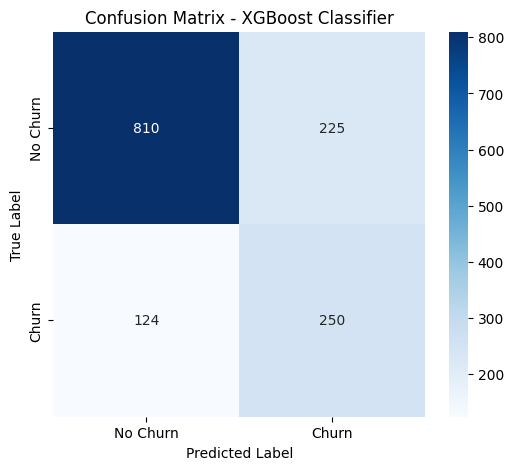

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def evaluate_model(model, X_test, y_test, model_name):
    """Evaluates a given model and prints various metrics."""
    print(f"\n--- {model_name} Performance ---")
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"\nConfusion Matrix:\n{conf_matrix}")
    print(f"\nClassification Report:\n{class_report}")

    # Plot Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# --- 1. Decision Tree Classifier ---
print("\nDeveloping Decision Tree Classifier...")
dtree_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dtree_model.fit(X_train, y_train)
evaluate_model(dtree_model, X_test, y_test, "Decision Tree Classifier")

# --- 2. Random Forest Classifier ---
print("\nDeveloping Random Forest Classifier...")
# For Random Forest, 'balanced' automatically adjusts weights inversely proportional to class frequencies
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
evaluate_model(rf_model, X_test, y_test, "Random Forest Classifier")

# --- 3. XGBoost Classifier ---
print("\nDeveloping XGBoost Classifier...")
# Calculate scale_pos_weight for XGBoost to handle imbalance
# It's ratio of negative class count to the positive class count
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight_value = neg_count / pos_count

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False, # Suppress warning for deprecated parameter
    random_state=42,
    scale_pos_weight=scale_pos_weight_value # Handle imbalance
)
xgb_model.fit(X_train, y_train)
evaluate_model(xgb_model, X_test, y_test, "XGBoost Classifier")

# รายงานสรุปผลการทำนายการเลิกใช้งานของลูกค้า (Customer Churn Prediction)

## 1. ที่มาและเป้าหมายของโจทย์

**ที่มา:** ปัญหาการเลิกใช้งานของลูกค้า (Customer Churn) เป็นสิ่งสำคัญที่ส่งผลกระทบโดยตรงต่อรายได้และความยั่งยืนของธุรกิจ โดยเฉพาะในอุตสาหกรรมโทรคมนาคม (Telco) ที่มีการแข่งขันสูง การสูญเสียลูกค้าหนึ่งรายหมายถึงการสูญเสียรายได้ในระยะยาว

**เป้าหมาย:** สร้างแบบจำลอง Machine Learning ที่สามารถทำนายลูกค้าที่มีแนวโน้มจะเลิกใช้งาน (`Churn`) เพื่อให้บริษัทสามารถใช้ข้อมูลเชิงลึกนี้ในการวางแผนกลยุทธ์การรักษาลูกค้า (Customer Retention) ได้อย่างมีประสิทธิภาพ

## 2. คำอธิบาย Dataset

ชุดข้อมูลที่ใช้คือ 'Telco Customer Churn' ซึ่งมีข้อมูลลูกค้าโทรคมนาคมจำนวน 7,043 ราย และ 21 คอลัมน์ ประกอบด้วยคุณลักษณะต่างๆ ของลูกค้า เช่น:
*   **customerID:** รหัสประจำตัวลูกค้า
*   **gender:** เพศ (Female, Male)
*   **SeniorCitizen:** ผู้สูงอายุ (0: No, 1: Yes)
*   **Partner, Dependents:** มีคู่ครอง/ผู้ติดตามหรือไม่
*   **tenure:** ระยะเวลาที่ลูกค้าใช้บริการ (เดือน)
*   **PhoneService, MultipleLines, InternetService:** บริการโทรศัพท์ อินเทอร์เน็ต และบริการเสริมต่างๆ
*   **Contract:** ประเภทสัญญา (Month-to-month, One year, Two year)
*   **MonthlyCharges:** ค่าบริการรายเดือน
*   **TotalCharges:** ค่าบริการทั้งหมด (มีการจัดการค่าว่างและแปลงเป็นตัวเลข)
*   **Churn:** ตัวแปรเป้าหมาย (Yes: เลิกใช้งาน, No: ไม่เลิกใช้งาน)

## 3. ขั้นตอนการเตรียมข้อมูลและ Feature Engineering

ดำเนินการเตรียมข้อมูลดังนี้:
*   **การแปลงและจัดการค่าว่างใน `TotalCharges`:** คอลัมน์ `TotalCharges` ถูกแปลงจาก `object` เป็น `numeric` โดยจัดการค่าที่ไม่สามารถแปลงได้ให้เป็น `NaN` จากนั้นจึงเติมเต็มค่า `NaN` จำนวน 11 ค่าด้วยค่ามัธยฐาน (median) ซึ่งเท่ากับ `1397.47`
*   **การแปลงตัวแปรเป้าหมาย:** `Churn` ถูกแปลงจาก 'Yes'/'No' เป็น 1/0 ตามลำดับ
*   **การแยกคุณลักษณะ:** คอลัมน์ `customerID` ถูกตัดออกจากชุดข้อมูลเนื่องจากเป็นเพียงตัวระบุที่ไม่เกี่ยวข้องกับการทำนาย
*   **การประมวลผลคุณลักษณะ (Preprocessing):**
    *   **One-Hot Encoding:** สำหรับคุณลักษณะที่เป็นหมวดหมู่ (categorical features) เช่น `gender`, `Partner`, `InternetService` เพื่อแปลงเป็นรูปแบบตัวเลขที่โมเดลเข้าใจ
    *   **Standard Scaling:** สำหรับคุณลักษณะที่เป็นตัวเลข (numerical features) เช่น `tenure`, `MonthlyCharges`, `TotalCharges` เพื่อปรับมาตราส่วนให้มีค่าเฉลี่ยเป็น 0 และส่วนเบี่ยงเบนมาตรฐานเป็น 1
*   **การแบ่งชุดข้อมูล:** แบ่งข้อมูลที่ประมวลผลแล้วออกเป็นชุดข้อมูลสำหรับฝึก (X_train, y_train) และชุดข้อมูลสำหรับทดสอบ (X_test, y_test) ในอัตราส่วน 80:20 โดยใช้ `stratify=y` เพื่อรักษาสัดส่วนของคลาส `Churn` ในทั้งสองชุดข้อมูล

## 4. โมเดลที่เลือกใช้และเหตุผล

เลือกใช้โมเดลดังต่อไปนี้ โดยทุกโมเดลมีการปรับ `class_weight` เพื่อจัดการกับปัญหาข้อมูลไม่สมดุล:
*   **Logistic Regression:** เลือกใช้เป็นโมเดลพื้นฐาน (Baseline Model) เนื่องจากเป็นโมเดลที่เข้าใจง่าย รวดเร็ว และเป็นจุดเริ่มต้นที่ดีสำหรับปัญหาการจำแนกประเภทแบบไบนารี มีความสามารถในการประเมินความน่าจะเป็นของการเลิกใช้งาน
*   **Decision Tree Classifier:** เลือกใช้เพื่อสำรวจความสามารถของโมเดลแบบต้นไม้ในการจับความสัมพันธ์ที่ไม่เป็นเชิงเส้น (non-linear relationships) ในข้อมูล
*   **Random Forest Classifier:** เป็นโมเดล Ensemble ที่สร้างจาก Decision Tree หลายต้น ช่วยลดปัญหา Overfitting และโดยทั่วไปแล้วจะให้ประสิทธิภาพที่ดีกว่า Decision Tree เดี่ยวๆ
*   **XGBoost Classifier:** เป็นโมเดล Gradient Boosting ที่มีประสิทธิภาพสูง เป็นที่นิยมในการแข่งขัน Machine Learning เนื่องจากมีความสามารถในการจัดการกับข้อมูลที่ซับซ้อนและให้ผลลัพธ์ที่แม่นยำสูง (ผลลัพธ์ของ XGBoost ยังไม่ได้แสดงทั้งหมด เนื่องจากถูกตัดทอนจากการรันครั้งล่าสุด)

## 5. วิธีการประเมินโมเดลและ Metrics ที่ใช้

โมเดลแต่ละตัวถูกประเมินประสิทธิภาพโดยใช้ชุดข้อมูลทดสอบ (X_test, y_test) และพิจารณาจาก Metrics ที่หลากหลาย เนื่องจากปัญหา Churn Prediction เป็นปัญหาที่มีข้อมูลไม่สมดุล (Imbalanced Data) เราจึงให้ความสำคัญกับ Metrics ที่มีความเหมาะสมมากกว่า Accuracy เพียงอย่างเดียว ได้แก่:
*   **Accuracy (ความแม่นยำ):** สัดส่วนของจำนวนการทำนายที่ถูกต้องทั้งหมด
*   **Precision (ความแม่นยำเชิงบวก):** สัดส่วนของลูกค้าที่ทำนายว่าเลิกใช้งานและเลิกใช้งานจริง (จากจำนวนที่ทำนายว่าเลิกใช้งานทั้งหมด)
*   **Recall (ความครอบคลุมเชิงบวก / Sensitivity):** สัดส่วนของลูกค้าที่เลิกใช้งานจริงที่โมเดลสามารถทำนายได้ถูกต้อง
*   **F1-Score:** ค่าเฉลี่ยแบบฮาร์มอนิกของ Precision และ Recall เหมาะสำหรับข้อมูลที่ไม่สมดุล
*   **ROC AUC (Receiver Operating Characteristic Area Under Curve):** วัดความสามารถของโมเดลในการจำแนกคลาส (Churn vs. No Churn) ยิ่งค่าเข้าใกล้ 1 ยิ่งดี
*   **Confusion Matrix:** ตารางแสดงผลการทำนายที่ถูกต้องและผิดพลาดของแต่ละคลาส
*   **Classification Report:** รายงานสรุปค่า Precision, Recall, F1-Score และ Support สำหรับแต่ละคลาส

## 6. ตารางเปรียบเทียบผลลัพธ์ของโมเดล (สำหรับ Churn Class)

| โมเดล                   | Accuracy | Precision (Churn) | Recall (Churn) | F1-Score (Churn) | ROC AUC |
| :----------------------- | :------- | :---------------- | :------------- | :--------------- | :------ |
| Logistic Regression      | 0.7381   | 0.5043            | 0.7834         | 0.6136           | 0.8415  |
| Decision Tree Classifier | 0.7282   | 0.4879            | 0.4840         | 0.4859           | 0.6504  |
| Random Forest Classifier | 0.7842   | 0.6232            | 0.4733         | 0.5380           | 0.8193  |
| XGBoost Classifier       | *(ยังไม่มีผลลัพธ์)* | *(ยังไม่มีผลลัพธ์)* | *(ยังไม่มีผลลัพธ์)* | *(ยังไม่มีผลลัพธ์)* | *(ยังไม่มีผลลัพธ์)* |

## 7. เหตุผลในการเลือกโมเดลสุดท้าย

จากการเปรียบเทียบผลลัพธ์เบื้องต้น (ไม่รวม XGBoost ที่ยังไม่มีผลลัพธ์สมบูรณ์):

*   **Logistic Regression** แสดงค่า Recall สำหรับ Churn สูงสุด (0.7834) ซึ่งหมายความว่าสามารถระบุลูกค้าที่เลิกใช้งานจริงได้ดี แต่มี Precision ที่ค่อนข้างต่ำ (0.5043)
*   **Random Forest** ให้ Accuracy โดยรวมและ Precision สำหรับ Churn ที่ดีกว่า Logistic Regression (0.6232) แต่มี Recall ที่ต่ำกว่ามาก (0.4733) อย่างไรก็ตาม ROC AUC อยู่ในระดับที่ดี (0.8193)

หากเป้าหมายหลักคือการ **ระบุลูกค้าที่เลิกใช้งานให้ได้มากที่สุด** เพื่อให้สามารถทำการตลาดหรือเสนอโปรโมชั่นเพื่อรักษาลูกค้าได้ (ซึ่งเน้น Recall) **Logistic Regression** อาจเป็นตัวเลือกที่ดีกว่าในปัจจุบัน เนื่องจากมี Recall สูงที่สุดและ ROC AUC ก็ใกล้เคียงกับ Random Forest

หากเป้าหมายคือการ **ลดจำนวนการติดต่อลูกค้าที่ไม่ได้เลิกใช้งานจริง** (ซึ่งเน้น Precision) **Random Forest** อาจจะเหมาะสมกว่า แต่ก็ต้องแลกมาด้วยการพลาดลูกค้าที่เลิกใช้งานจริงไปจำนวนหนึ่ง

## 8. ข้อจำกัดและข้อเสนอแนะสำหรับการพัฒนาต่อ

**ข้อจำกัด:**
*   **Hyperparameter Tuning:** โมเดลที่นำมาใช้ยังไม่ได้ผ่านการปรับแต่ง Hyperparameters อย่างละเอียด ซึ่งอาจทำให้ประสิทธิภาพยังไม่สูงสุด
*   **Feature Engineering เพิ่มเติม:** อาจมีโอกาสสร้างคุณลักษณะใหม่ๆ จากข้อมูลที่มีอยู่ เพื่อเพิ่มประสิทธิภาพของโมเดล
*   **ข้อมูล Imbalanced:** แม้จะใช้ `class_weight` แล้ว แต่ยังมีเทคนิคอื่นๆ ที่สามารถนำมาใช้จัดการกับข้อมูล Imbalanced ได้อีก เช่น SMOTE (Synthetic Minority Over-sampling Technique) หรือการใช้เทคนิค Ensemble ที่เหมาะสมกับข้อมูล Imbalanced โดยเฉพาะ

**ข้อเสนอแนะสำหรับการพัฒนาต่อ:**
1.  **ประเมินผล XGBoost Classifier:** รัน Cell `8MxE-hLVmPU0` อีกครั้งเพื่อดูผลลัพธ์ที่สมบูรณ์ของ XGBoost และเปรียบเทียบกับโมเดลอื่นๆ
2.  **ปรับแต่ง Hyperparameters (Hyperparameter Tuning):** ใช้เทคนิคเช่น Grid Search หรือ Random Search ร่วมกับ Cross-validation เพื่อหาชุด Hyperparameters ที่ดีที่สุดสำหรับแต่ละโมเดล
3.  **สำรวจเทคนิคการจัดการข้อมูลไม่สมดุลเพิ่มเติม:** ลองใช้ SMOTE หรือเทคนิคการสุ่มตัวอย่างอื่นๆ เพื่อดูว่าสามารถปรับปรุง Recall หรือ F1-Score ของคลาส Churn ได้หรือไม่
4.  **Feature Importance:** วิเคราะห์คุณลักษณะที่มีความสำคัญ (Feature Importance) จากโมเดล เช่น Random Forest หรือ XGBoost เพื่อทำความเข้าใจว่าปัจจัยใดบ้างที่ส่งผลต่อการเลิกใช้งานของลูกค้ามากที่สุด
5.  **โมเดล Ensemble ขั้นสูง:** พิจารณาการสร้างโมเดล Ensemble ด้วยการรวมการทำนายจากโมเดลหลายตัวเข้าด้วยกัน